# 07_降维模型-UMAP

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/MNIST/raw/train-images-idx3-ubyte.gz`、`dataset/MNIST/raw/train-labels-idx1-ubyte.gz`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 读取本地 MNIST IDX 文件，固定分层抽取 2000 张图像做传统降维；可调整 sample_size。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文想要和大家聊的算法模型是：UMAP ！

UMAP，全称：Uniform Manifold Approximation and Projection\~

UMAP 本身是一种用于降维和数据可视化的技术。当初是由Leland McInnes、John Healy和James Melville于2018年提出。UMAP的主要目的是将高维数据映射到低维空间（通常是2D或3D），使得高维空间中的结构和关系在低维空间中得以保留。

给大家举一个简单的例子，就明白它的作用了：

你有一个非常复杂的迷宫，这个迷宫有很多房间和走廊，而且这些房间和走廊都很狭窄、弯曲。如果你站在迷宫的一个房间里，你很难看清整个迷宫的全貌，但你可以看到附近的几个房间和走廊。

UMAP 就像是一种神奇的地图，它能帮助你把这个复杂的迷宫压缩成一张简单的地图。在这张地图上，迷宫的结构和路径都能被清楚地看到。UMAP通过理解和保持迷宫中房间和走廊之间的相对关系，把迷宫从一个复杂的3D结构转换成一张2D的平面图。

这样，当你看这张2D的地图时，即使原本的迷宫非常复杂，你也能轻松地看到迷宫的整体布局和重要的路径。这对我们分析高维数据（例如图像、文本或基因数据）非常有用，因为我们可以通过UMAP把数据降维到2D或3D，然后用眼睛直观地观察数据的模式和结构。

## 理论基础

UMAP的数学基础主要涉及拓扑数据分析、流形学习和优化技术。

**1. 拓扑空间和流形假设**：

- UMAP假设数据点位于某个高维流形上。流形是一个局部欧几里得空间的拓扑空间，可以理解为高维空间中的“曲面”。
- UMAP通过邻域图（neighborhood graph）来捕捉高维流形的局部结构。

**2. 构建高维空间中的图**：

- 对于每个数据点，UMAP首先找到其最近邻数据点（使用k-近邻算法）。
- 定义加权边，边的权重由高斯核函数计算，表示两个点之间的相似度。具体来说，权重计算如下：  
$w_{ij} = \exp\left(-\frac{{d_{ij}^2 - \rho_i}}{{\sigma_i}}\right)$

其中，$d_{ij}$是数据点 $i$和 $j$之间的距离，$\rho_i$是用于控制局部密度的距离阈值， $\sigma_i$是局部尺度参数。

**3. 低维空间中的布局**：

- 低维空间中也构建一个邻域图。低维空间中的边权重使用二项分布近似：  
$w'_{ij} = \frac{1}{1 + a \cdot (d'_{ij})^{2b}}$  
其中，$d'_{ij}$是低维空间中数据点 $i$和 $j$之间的距离，$a$是超参数，用于调整低维空间中的距离分布。

**4. 优化目标函数**：

- 通过最小化高维和低维空间中的图之间的差异来优化数据点的低维嵌入。UMAP使用交叉熵作为优化目标函数：  
$C = \sum_{(i,j)} w_{ij} \log\left(\frac{w_{ij}}{w'_{ij}}\right) + (1 - w_{ij}) \log\left(\frac{1 - w_{ij}}{1 - w'_{ij}}\right)$
- 该目标函数衡量高维和低维空间中的邻域相似度的差异。通过最小化这个目标函数，可以获得一个低维表示，使得低维空间中相似的数据点仍然保持相似，不相似的数据点保持不相似。

### 算法流程

1. **数据预处理**：标准化输入数据，使得每个特征的均值为0，标准差为1。
2. **构建高维邻域图**：

   - 使用k-近邻算法找到每个数据点的k个最近邻。
   - 计算高维邻域图中的边权重，使用高斯核函数确定相似度。
3. **初始化低维嵌入**：使用随机初始化或其他降维算法（如PCA）来生成低维嵌入的初始点。
4. **优化低维嵌入**：通过最小化目标函数来优化低维嵌入。常用的方法是梯度下降，具体步骤：

   1. 计算目标函数的梯度。
   2. 根据梯度更新低维嵌入的位置。
   3. 重复上述步骤，直到目标函数收敛或达到预定的迭代次数。
5. **后处理**：

   - 对低维嵌入结果进行可视化。
   - 根据需要进行进一步的分析或聚类。

通过上述步骤，UMAP能够将高维数据映射到低维空间，同时保留数据的局部和全局结构，使得数据的模式和关系在低维空间中更加清晰和易于解释。

## 完整案例

**使用UMAP处理和可视化MNIST数据集**

MNIST数据集包含60000个手写数字图像（28x28像素），每个图像代表一个数字（0-9）。我们将使用UMAP将图像数据降维到2D，并进行可视化，同时展示算法优化。

**1. 导入必要的库**

In [2]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
from notebook_support import load_local_mnist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 用于计时优化
import time

**2. 加载和预处理数据**

In [3]:
# 加载MNIST数据集
mnist = load_local_mnist()
X, y = mnist.data, mnist.target.astype(int)

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 进行PCA初步降维
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

**3. 应用UMAP**

In [4]:
# 定义UMAP参数
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)

# 计时UMAP计算时间
start_time = time.time()
X_umap = umap_model.fit_transform(X_pca)
end_time = time.time()

print(f"UMAP fitting time: {end_time - start_time:.2f} seconds")

/tmp/ml-notebook-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fitting time: 6.20 seconds


**4. 可视化结果**

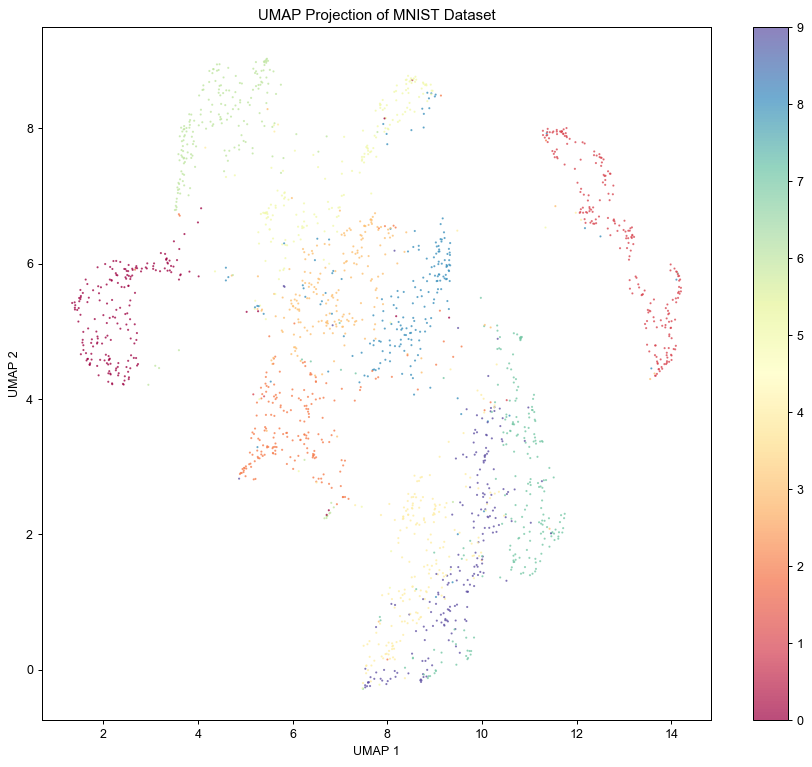

In [5]:
# 创建一个颜色映射
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='Spectral', s=0.5, alpha=0.7)
plt.colorbar(scatter)
plt.title('UMAP Projection of MNIST Dataset')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_037.png)

**5. 算法优化和可视化**

/tmp/ml-notebook-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Optimized UMAP fitting time: 3.67 seconds


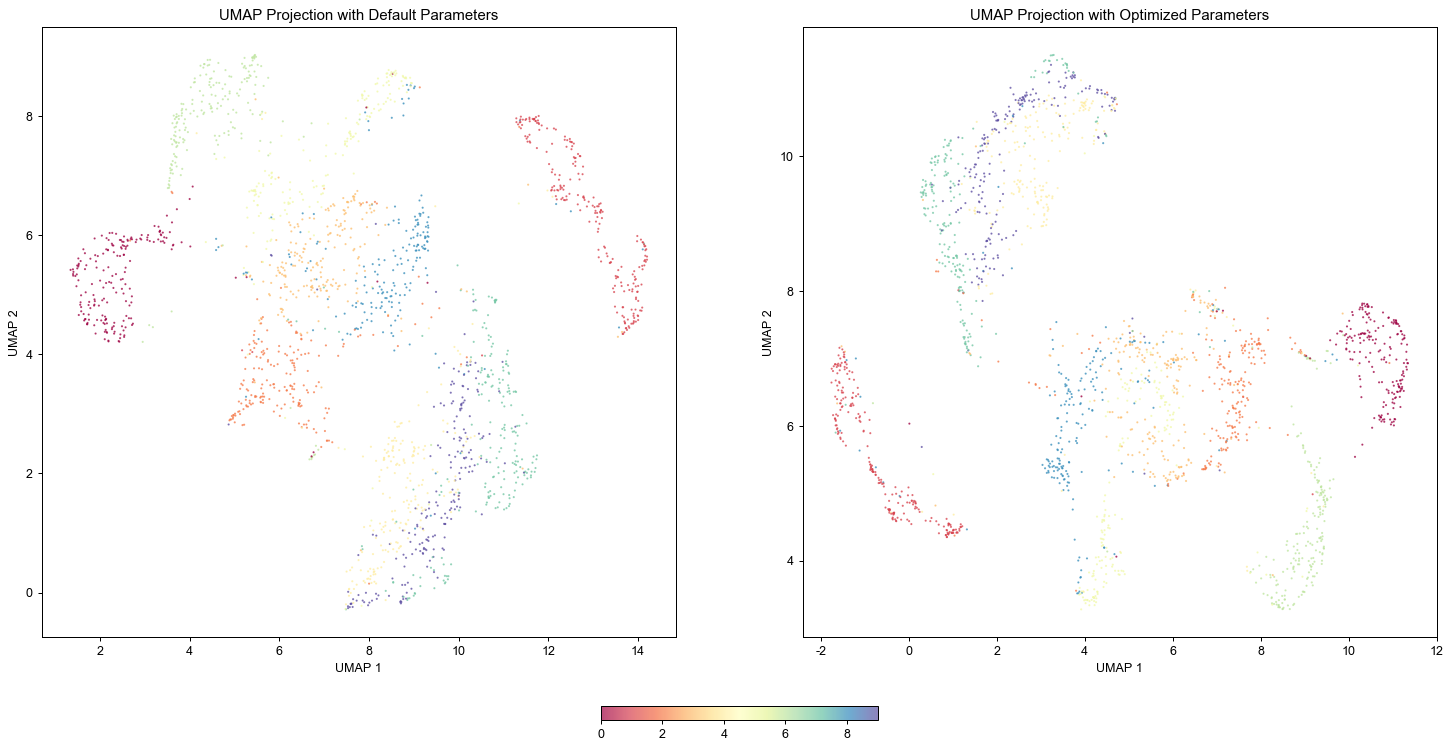

In [6]:
# 优化参数
umap_model_optimized = umap.UMAP(n_neighbors=30, min_dist=0.05, n_components=2, metric='cosine', random_state=42)

# 计时优化后的UMAP计算时间
start_time = time.time()
X_umap_optimized = umap_model_optimized.fit_transform(X_pca)
end_time = time.time()

print(f"Optimized UMAP fitting time: {end_time - start_time:.2f} seconds")

# 创建复杂的可视化
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# 原始UMAP
scatter1 = ax[0].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='Spectral', s=0.5, alpha=0.7)
ax[0].set_title('UMAP Projection with Default Parameters')
ax[0].set_xlabel('UMAP 1')
ax[0].set_ylabel('UMAP 2')

# 优化后UMAP
scatter2 = ax[1].scatter(X_umap_optimized[:, 0], X_umap_optimized[:, 1], c=y, cmap='Spectral', s=0.5, alpha=0.7)
ax[1].set_title('UMAP Projection with Optimized Parameters')
ax[1].set_xlabel('UMAP 1')
ax[1].set_ylabel('UMAP 2')

# 添加颜色条
fig.colorbar(scatter2, ax=ax, orientation='horizontal', fraction=0.02, pad=0.1)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_038.png)

整个过程其实非常明显了：

1. **数据加载和预处理**：

   - 使用 `load_local_mnist()` 从本地 IDX 文件读取 MNIST 教学样本，并使用`StandardScaler`进行标准化处理。
   - 使用PCA将数据降维到50维，这不仅减少了UMAP的计算负担，还能去除噪声。
2. **UMAP应用**：

   - 使用默认参数和优化参数分别进行UMAP降维。
   - `n_neighbors`决定了局部邻域的大小，`min_dist`控制了低维空间中点的密集程度，`metric`选择距离度量。
3. **可视化**：

   - 使用Matplotlib进行2D可视化。颜色条显示不同数字的分布。
   - 对比默认参数和优化参数的UMAP降维结果，观察优化对可视化效果的影响。

整个步骤，给大家解释了UMAP的应用过程，包括数据预处理、降维、优化和可视化。这种方法适用于处理大规模、高维数据集，尤其是在探索数据结构和模式时非常有用。

## 应用场景

UMAP适用于以下类型的问题：

1. **降维**：

   - 高维数据的可视化。
   - 数据的预处理，以减少特征维度。
2. **数据探索和模式发现**：

   - 发现数据中的聚类和群体结构。
   - 理解数据的内在结构和分布。
3. **加速下游任务**：

   - 在降维后进行分类、聚类等任务，提升计算效率。

**优点**：

1. **保持局部和全局结构**：能够在低维空间中同时保持数据的局部邻域关系和全局结构。
2. **速度快**：相比于t-SNE，UMAP的计算速度更快，特别适合处理大规模数据。
3. **参数调整灵活**：提供了丰富的参数（如邻居数和最小距离）来调整降维结果，适应不同的应用需求。
4. **良好的可视化效果**：在二维和三维空间中，UMAP的可视化效果通常更为清晰和直观。

**缺点**：

1. **对参数敏感**：降维结果对参数（如邻居数和最小距离）较为敏感，需要仔细调整。
2. **难以解释**：虽然UMAP提供了很好的可视化效果，但降维后的新特征难以直观解释。
3. **高计算资源**：对于非常大的数据集，UMAP的内存和计算资源需求较高。

### 运用时的前提条件

1. **高维数据**：适用于处理高维数据（如图像、文本、基因组数据等）。
2. **合理的参数选择**：需要根据具体数据和应用场景选择合适的参数，以获得最佳效果。
3. **数据标准化**：输入数据应进行标准化或归一化处理，以提高降维效果。